In [1]:
# %%
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import pandas as pd
import numpy as np

from src.data_loader import DataLoader
from src.features_backup_highest import FeatureEngineer
from src.models_backup_highest import HybridForecaster
from src.validation import WalkForwardBacktester
from src.visualization import ModelVisualizer

In [4]:
# %%
loader = DataLoader(raw_data_path='../data/raw')
raw_data = loader.load_all_data()

sales_df = raw_data['sales']
promos_df = raw_data['promotions']
traffic_df = raw_data['web_traffic']

# %%
engineer = FeatureEngineer(
    sales_df=sales_df,
    promos_df=promos_df
)

master_df = engineer.run_pipeline()

print(master_df.head())
print(master_df.shape)

🚀 Loading raw data...


e:\DATATHON 2026\datathon-2026-round-1\notebook\..\src\data_loader.py:21: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=date_cols)


✅ Loaded 14 tables
⚙️ Running feature engineering...
✅ Feature shape: (3833, 29)
        date     revenue        cogs  t  t2  t3  dayofweek  month  day  \
0 2012-07-04  5123547.94  3982991.19  0   0   0          2      7    4   
1 2012-07-05  2751773.45  2150580.23  1   1   1          3      7    5   
2 2012-07-06  3054029.42  2517632.84  2   4   8          4      7    6   
3 2012-07-07  2667930.94  2108246.62  3   9  27          5      7    7   
4 2012-07-08  2360851.90  1808622.79  4  16  64          6      7    8   

   is_weekend  ...     cos_2     sin_3     cos_3     sin_4     cos_4  \
0           0  ...  0.992749 -0.179767 -0.983709  0.238673  0.971100   
1           0  ...  0.988023 -0.230306 -0.973118  0.304921  0.952378   
2           0  ...  0.982126 -0.280231 -0.959933  0.369725  0.929141   
3           1  ...  0.975065 -0.329408 -0.944188  0.432776  0.901502   
4           1  ...  0.966848 -0.377708 -0.925925  0.493776  0.869589   

      sin_5     cos_5  active_promos  max

In [5]:
# %%
print("NaN revenue:", master_df['revenue'].isna().sum())
print("Min revenue:", master_df['revenue'].min())
print("Max revenue:", master_df['revenue'].max())

neg = master_df[master_df['revenue'] < 0]
if not neg.empty:
    print("⚠️ Found negative revenue")
    display(neg.head())

NaN revenue: 0
Min revenue: 279813.94
Max revenue: 20905271.35


In [6]:
# 3. Khởi tạo Mô hình Hybrid (Option 1)
model = HybridForecaster()

In [7]:
# 4. Thiết lập các Fold cắt dữ liệu (Mô phỏng mù 1.5 năm như Kaggle test set)
# Tập sales.csv có dữ liệu từ 2012-07-04 đến 2022-12-31
# Ta sẽ lùi lại trong quá khứ để tạo 2 cửa sổ test dài 1.5 năm (18 tháng)
validation_splits = [
    {
        # Fold 1: Train đến hết 2019, Test 1.5 năm (đến giữa 2021)
        'train_end': '2019-12-31',
        'val_end': '2021-06-30'
    },
    {
        # Fold 2: Train đến giữa 2021, Test 1.5 năm (đến hết 2022)
        'train_end': '2021-06-30',
        'val_end': '2022-12-31'
    }
]

In [8]:
# 5. Khởi động Lò Bát Quái
backtester = WalkForwardBacktester(model=model, df=master_df)
results = backtester.run_backtest(validation_splits)


🚀 Running 2 folds backtest...

--- FOLD 1 ---
Train size: 2737
Val size  : 547
✅ Hybrid (Ridge + XGB) trained
MAE : 2198070.28
RMSE: 2551518.71
R2  : -1.1261

--- FOLD 2 ---
Train size: 3284
Val size  : 549


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=8.92798e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


✅ Hybrid (Ridge + XGB) trained
MAE : 720237.62
RMSE: 916312.50
R2  : 0.6524

✅ Backtest completed



📊 METRICS TABLE:
   Fold           MAE          RMSE        R2
0     1  2.198070e+06  2.551519e+06 -1.126144
1     2  7.202376e+05  9.163125e+05  0.652398

📊 AVERAGE PERFORMANCE:
           Average
Fold  1.500000e+00
MAE   1.459154e+06
RMSE  1.733916e+06
R2   -2.368728e-01


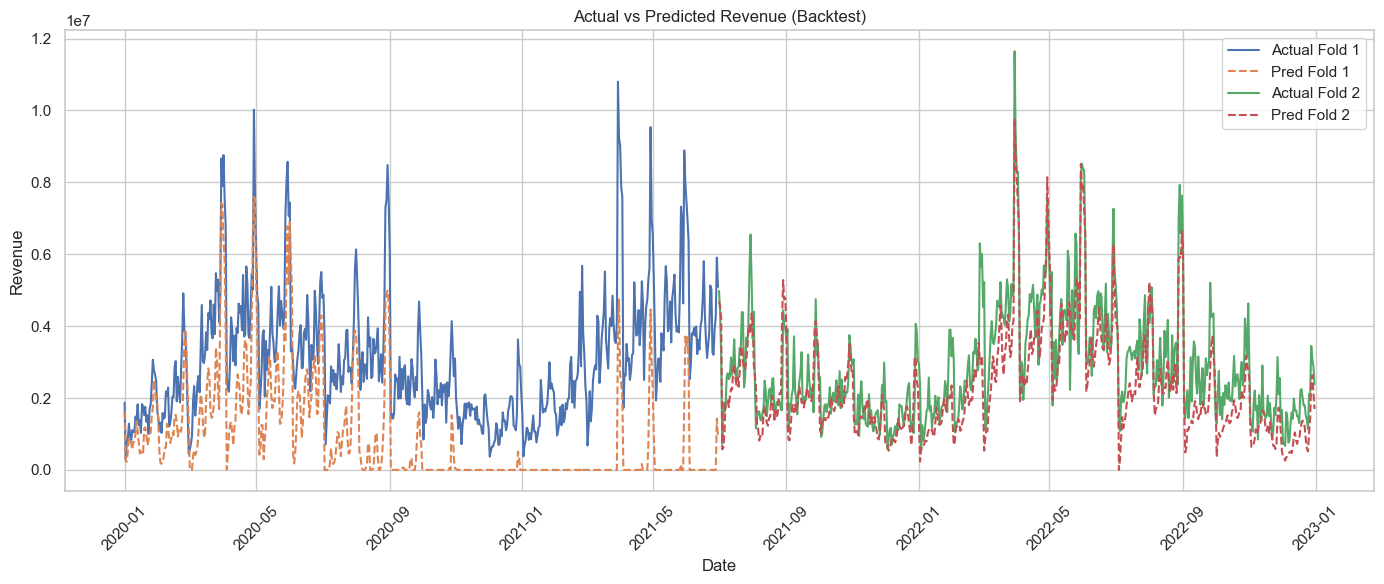

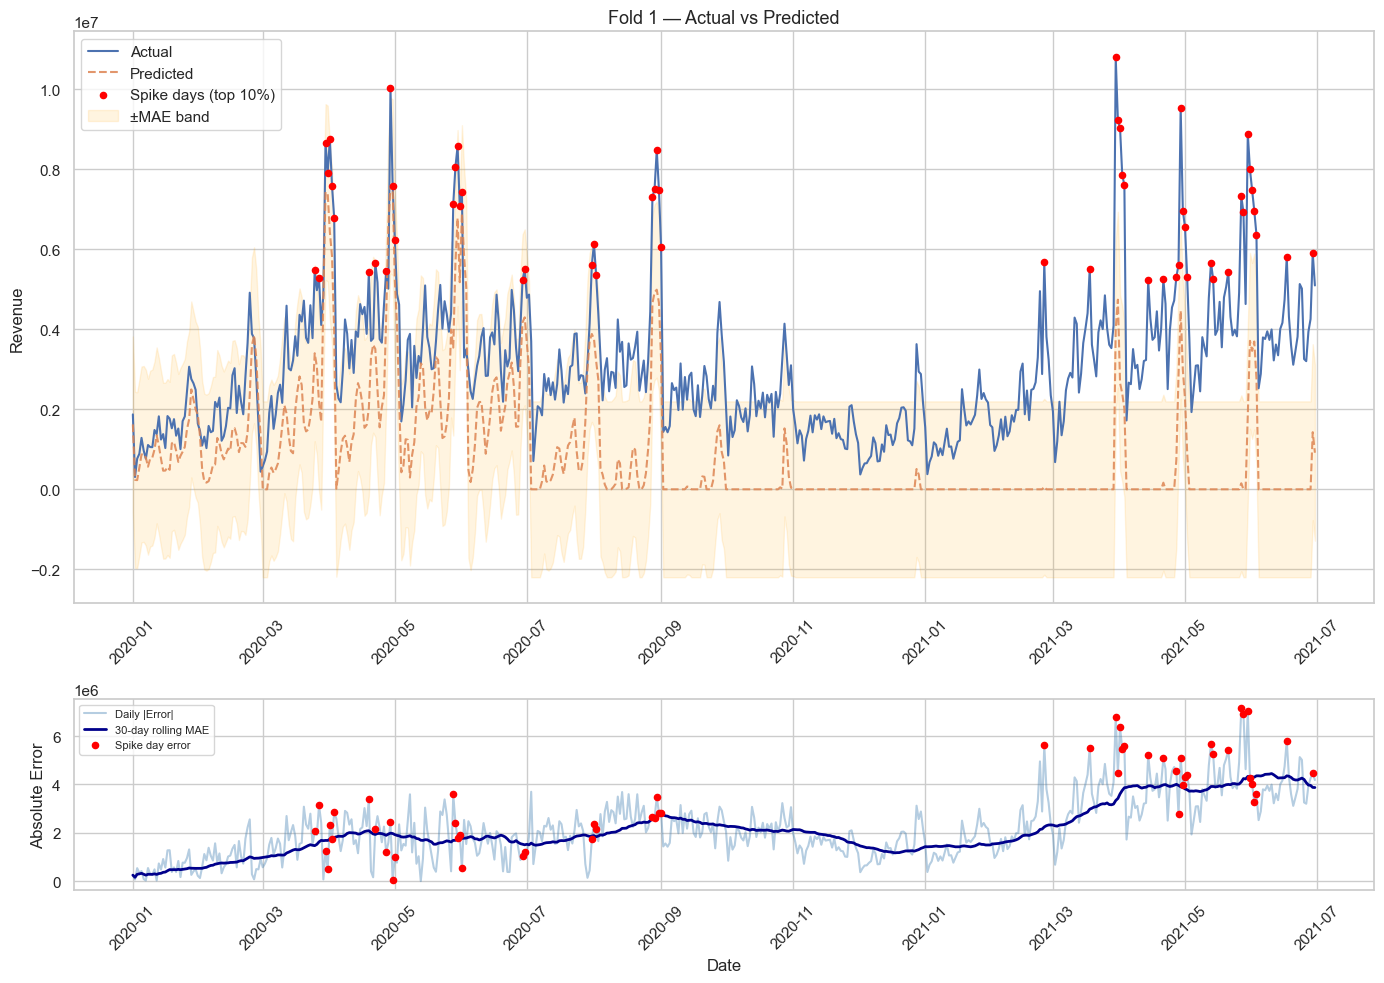


📊 Fold 1 Spike Decomposition:
   Spike threshold (p90) : 5,191,393
   Spike days            : 55 / 547
   MAE spike days        : 3,550,097
   MAE non-spike days    : 2,046,929
   % of total MAE from spikes: 16.2%



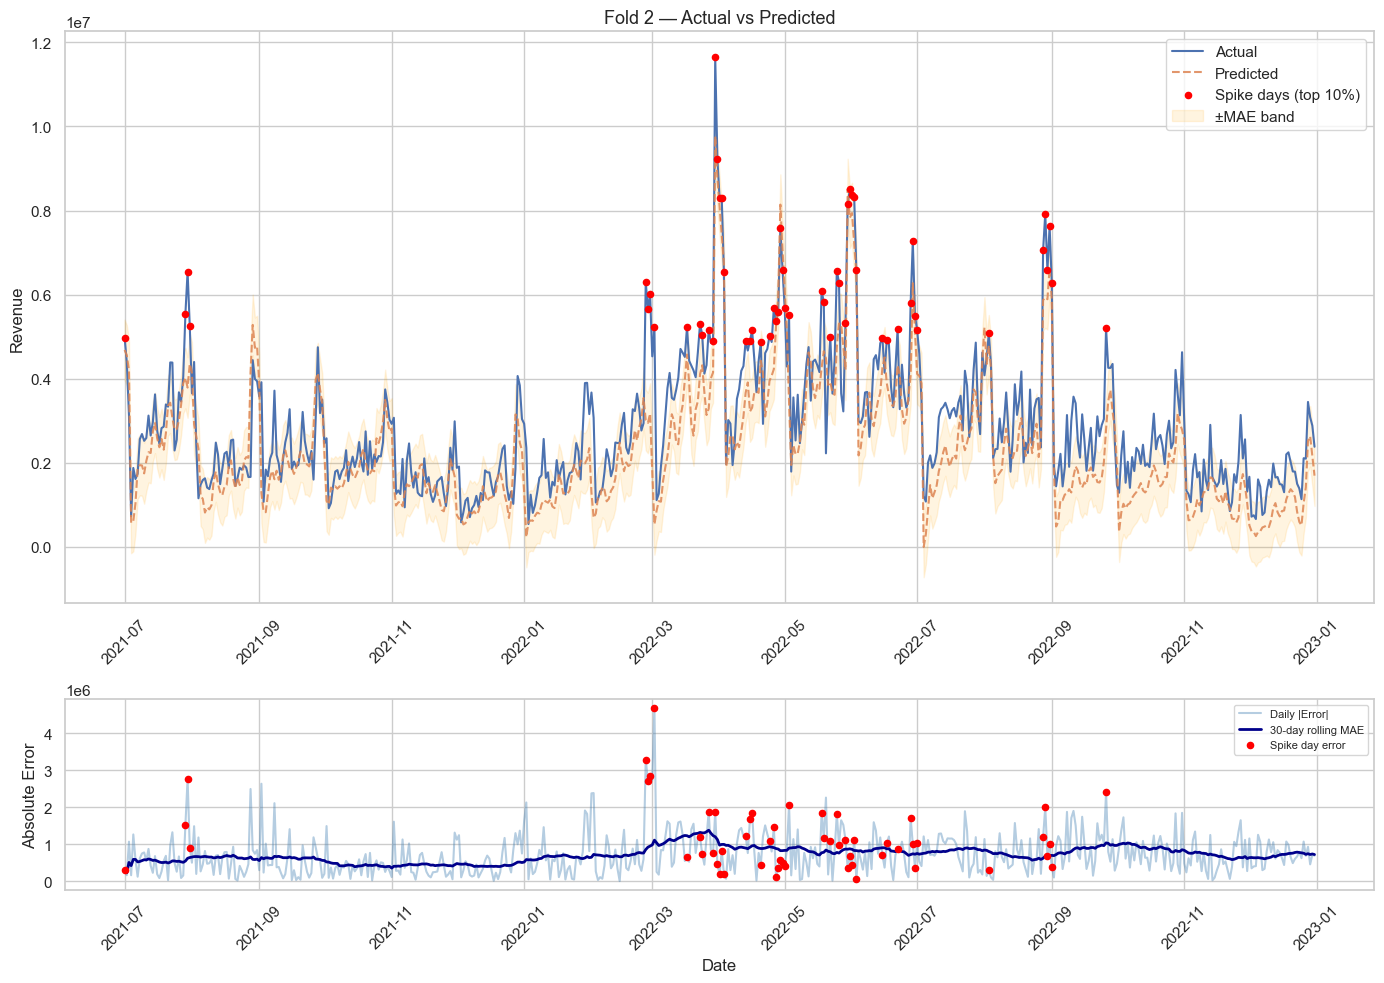


📊 Fold 2 Spike Decomposition:
   Spike threshold (p90) : 4,873,922
   Spike days            : 55 / 549
   MAE spike days        : 1,176,104
   MAE non-spike days    : 669,483
   % of total MAE from spikes: 16.4%



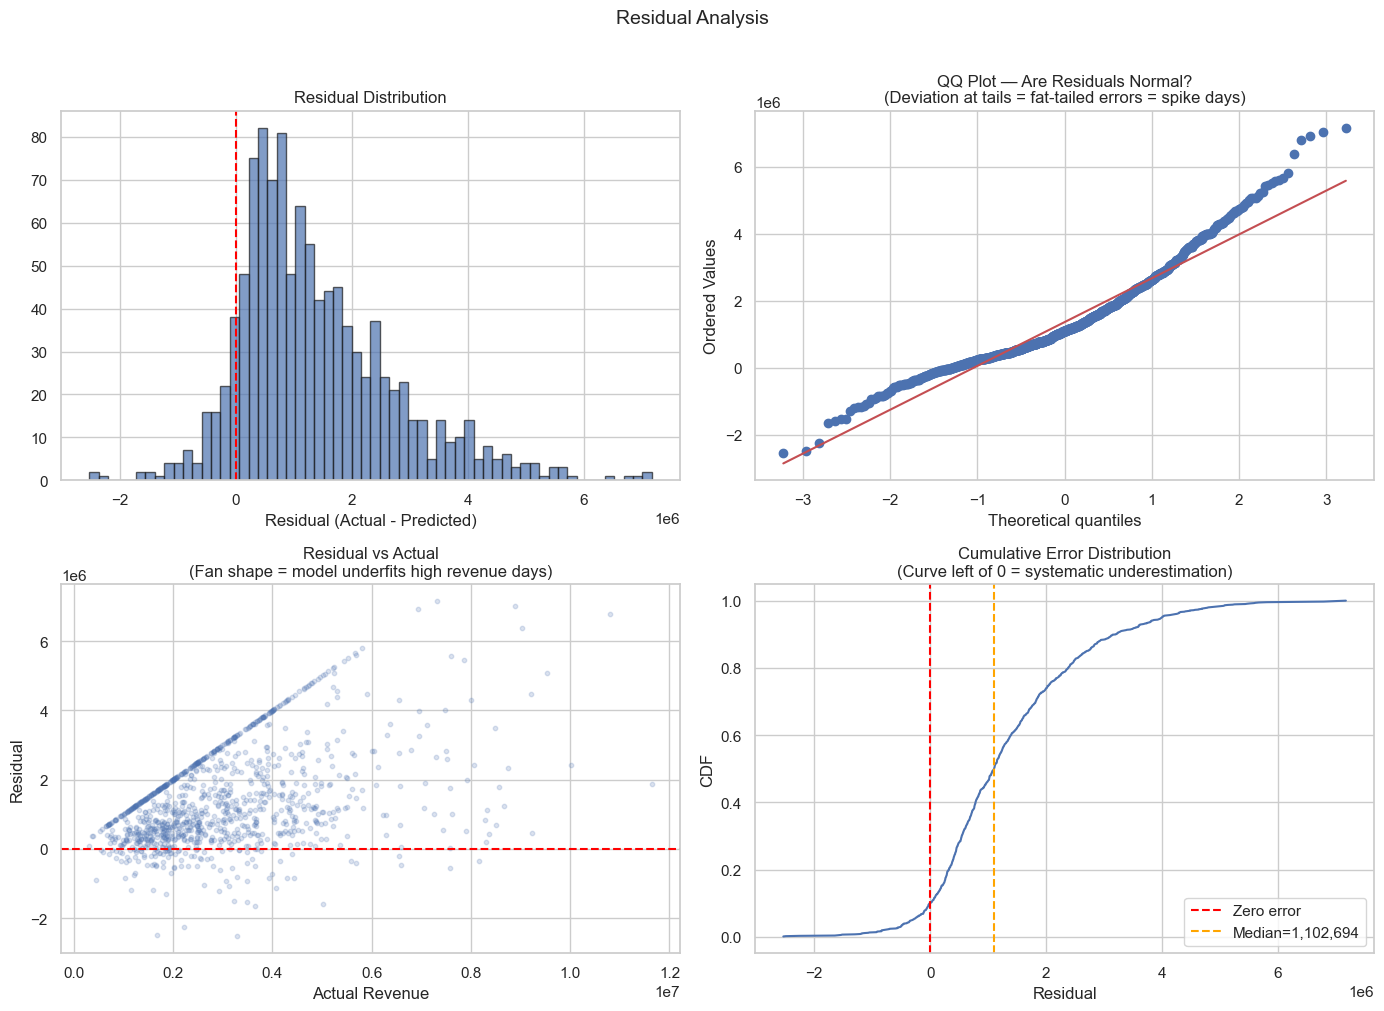


📊 Residual Summary:
   Mean   : 1,364,959  ← should be near 0 (no bias)
   Median : 1,102,694  ← robust bias indicator
   Std    : 1,344,117
   Skew   : 0.967  ← >0 = under-predict right tail
   Kurtosis: 1.421  ← >3 = fat tails (spike misses)


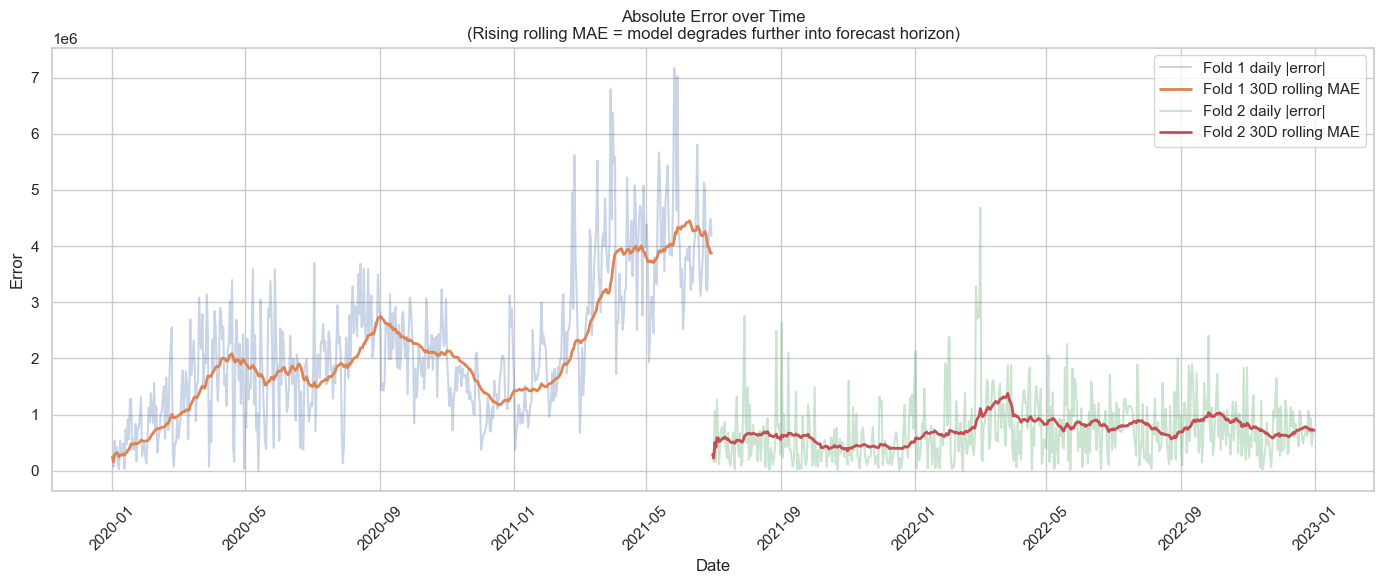

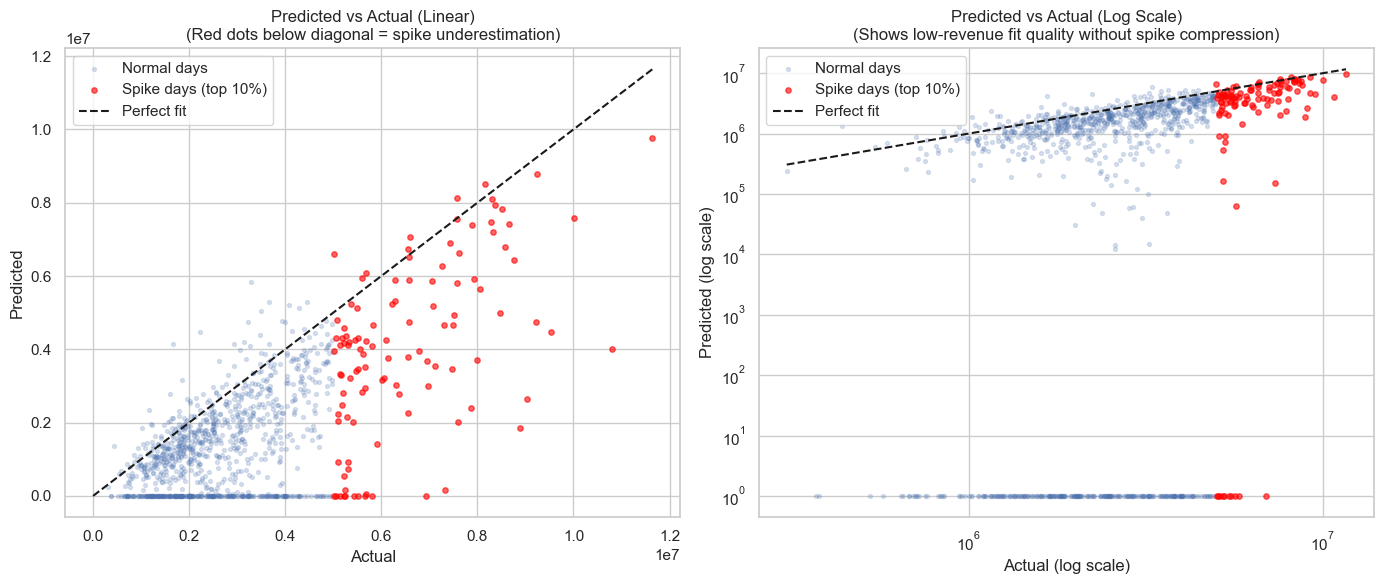

In [9]:
# KHỞI ĐỘNG CỖ MÁY TRỰC QUAN HÓA
visualizer = ModelVisualizer()

# bảng metrics
visualizer.plot_metrics_table(results)

# plot tổng
visualizer.plot_backtest_results(results)

# từng fold
visualizer.plot_each_fold(results)

# residual
visualizer.plot_residuals(results)

# error theo time
visualizer.plot_error_over_time(results)

# scatter
visualizer.plot_scatter(results)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OBJECT COLS: Index([], dtype='object')


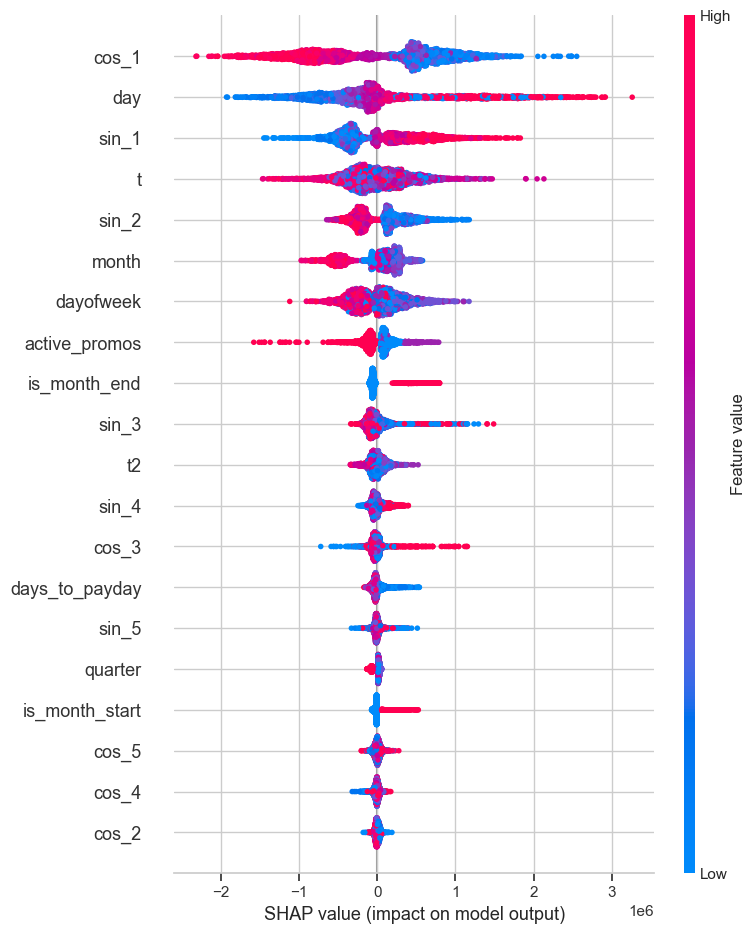

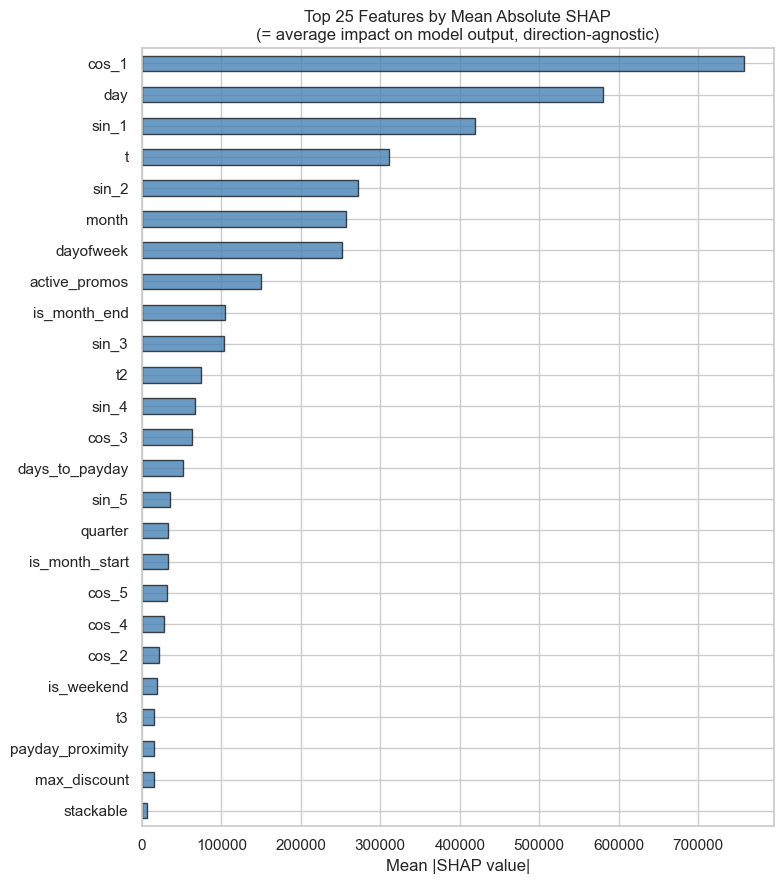

In [10]:
visualizer = ModelVisualizer()
# shap
train_df_final_fold = results[-1]['train_df']
visualizer.plot_shap_summary(model, train_df_final_fold)

In [11]:
# ==========================================
# PHẦN 4: HUẤN LUYỆN TOÀN BỘ & XUẤT KAGGLE
# ==========================================
print("\n🚀 ĐANG HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ĐỂ NỘP KAGGLE...")

# Fit model trên 100% dữ liệu có sẵn (tới 31/12/2022)
model.fit(master_df)

# Lấy template file nộp
sample_sub = raw_data['sample_submission']

# Đảm bảo trục thời gian liên tục từ 01/01/2023 đến 01/07/2024
test_dates = pd.DataFrame({
    'date': pd.to_datetime(sample_sub['date'])
})

print(test_dates.head())

# --- BƯỚC QUAN TRỌNG: Tạo Features cho tập Test ---

# ✅ CONCAT để tạo lag đúng
combined_sales = pd.concat([
    master_df[['date', 'revenue', 'cogs']],  # full history
    test_dates                               # future
], ignore_index=True)

# Feature engineering trên toàn bộ timeline
test_engineer = FeatureEngineer(
    sales_df=combined_sales,
    promos_df=raw_data['promotions']
)

master_test_df = test_engineer.run_pipeline()

# ✅ CHỈ lấy phần test
final_test_features = master_test_df[
    master_test_df['date'] >= '2023-01-01'
].copy()

# DỰ BÁO REVENUE
test_preds = model.predict(final_test_features)
sample_sub['revenue'] = test_preds

# ⚠️ PRO TIP CHO CỘT COGS (GIÁ VỐN)
# Tính tỷ lệ lịch sử rồi nhân ngược lại
historical_cogs_ratio = (
    master_df['cogs'].sum() / master_df['revenue'].sum()
)

sample_sub['cogs'] = sample_sub['revenue'] * historical_cogs_ratio


# Sửa lại tên cột nếu cần (ví dụ: 'date' -> 'Date', 'revenue' -> 'Revenue', 'cogs' -> 'COGS')
sample_sub.rename(columns={
    'date': 'Date',
    'revenue': 'Revenue',
    'cogs': 'COGS'
}, inplace=True)

# Lưu file Submission
sample_sub.to_csv('submission_tune_on_old.csv', index=False)

print("✅ ĐÃ LƯU FILE submission.csv THÀNH CÔNG! SẴN SÀNG UPLOAD LÊN KAGGLE.")


🚀 ĐANG HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ĐỂ NỘP KAGGLE...


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.80982e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


✅ Hybrid (Ridge + XGB) trained
        date
0 2023-01-01
1 2023-01-02
2 2023-01-03
3 2023-01-04
4 2023-01-05
⚙️ Running feature engineering...
✅ Feature shape: (4381, 29)
✅ ĐÃ LƯU FILE submission.csv THÀNH CÔNG! SẴN SÀNG UPLOAD LÊN KAGGLE.


In [12]:
final_test_features.head()

,date,revenue,cogs,t,t2,t3,dayofweek,month,day,is_weekend,...,cos_2,sin_3,cos_3,sin_4,cos_4,sin_5,cos_5,active_promos,max_discount,stackable
3833,2023-01-01,0.0,0.0,3833,14691889,56314010537,6,1,1,1,...,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.91,20.0,1.0
3834,2023-01-02,0.0,0.0,3834,14699556,56358097704,0,1,2,0,...,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.81,20.0,1.0
3835,2023-01-03,0.0,0.0,3835,14707225,56402207875,1,1,3,0,...,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.00,0.0,0.0
3836,2023-01-04,0.0,0.0,3836,14714896,56446341056,2,1,4,0,...,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.00,0.0,0.0
3837,2023-01-05,0.0,0.0,3837,14722569,56490497253,3,1,5,0,...,0.985220,0.255353,0.966848,0.337523,0.941317,0.417194,0.908818,0.00,0.0,0.0


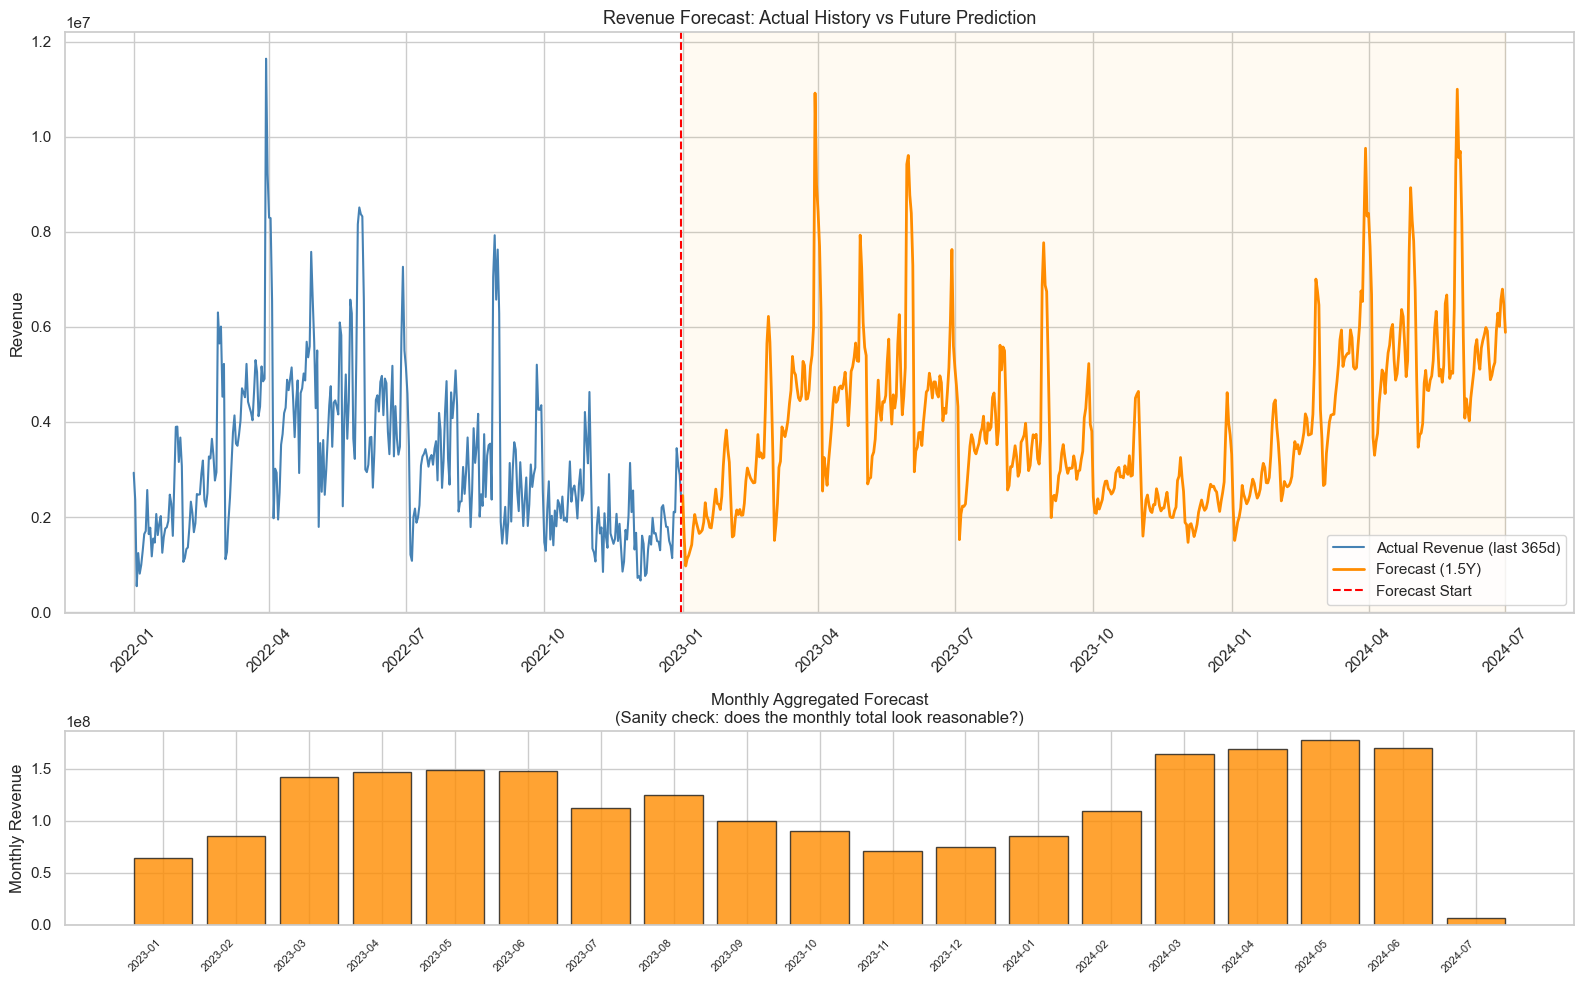


📊 Forecast Summary:
   Period         : 2023-01-01 → 2024-07-01
   Days forecast  : 548
   Total forecast : 2,185,575,288
   Daily avg      : 3,988,276
   Daily max      : 11,001,001
   Daily min      : 970,752
   Days with pred=0: 0


In [13]:
visualizer = ModelVisualizer()

# forecast df (future)
test_df = final_test_features.copy()

visualizer.plot_forecast(
    train_df=master_df,
    test_df=test_df,
    model=model,
    date_col='date',
    target_col='revenue'
)